# SimpleCNN 訓練 — 單階段 9 類分類
每個 Cell 對應一個獨立步驟，可分開執行：
- **Cell 1**：環境設定（只需執行一次）
- **Cell 2**：實驗設定（換參數只改這裡，改完重跑 Cell 4+）
- **Cell 3**：載入資料（只需執行一次，換設定不需重跑）
- **Cell 4**：準備資料集與模型
- **Cell 5**：訓練（含即時圖表）
- **Cell 6**：測試集評估
- **Cell 7**：最終圖表
- **Cell 8**：儲存結果（選用）

In [4]:
import sys
sys.path.insert(0, '..')
# Cell 1 — 環境設定（只需執行一次）
%matplotlib inline
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate

from engine.trainer import print_metrics, print_per_class_f1, run_one_epoch, train_model
from engine.visualize import plot_cm, plot_history
from models.simple_cnn import SimpleCNN
from constant import LABEL_MAP
from data.dataset import WaferSimpleDataset, extract_labeled_patterned_data, load_raw_data, make_dataloaders, split_df
from utils import make_output_dir, save_results, set_seed, EpochTimer


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"使用裝置：{device}")

使用裝置：cpu


In [ ]:
# Cell 2 — 實驗設定（換參數只改這裡，改完重跑 Cell 4+）
EXPERIMENT_NAME    = "simple_DW_seed42"
IMAGE_SIZE         = (64, 64)
BATCH_SIZE         = 32
EPOCHS             = 40
LR                 = 1e-3
RANDOM_SEED        = 42

set_seed(RANDOM_SEED)

In [6]:
# Cell 3 — 載入資料（只需執行一次，換設定不用重跑）
print("下載/讀取 WM-811K 資料集...")
df = load_raw_data()
df_with_label, df_with_pattern, _ = extract_labeled_patterned_data(df)
print(f"有標籤資料：{len(df_with_label)} 筆")

下載/讀取 WM-811K 資料集...
有標籤資料：172950 筆


In [7]:
# Cell 4 — 準備資料集與模型
train_df, val_df, test_df = split_df(
    df_with_label, stratify_col="failureType", random_seed=RANDOM_SEED,
)

num_classes = len(LABEL_MAP)
datasets = {
    "train": WaferSimpleDataset(train_df, image_size=IMAGE_SIZE),
    "val":   WaferSimpleDataset(val_df, image_size=IMAGE_SIZE),
    "test":  WaferSimpleDataset(test_df, image_size=IMAGE_SIZE),
}
dataloaders = make_dataloaders(datasets, BATCH_SIZE)

model = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
print(f"模型與資料集準備完成，類別數：{num_classes}")

模型與資料集準備完成，類別數：9


In [8]:
# Cell 5 — 訓練
timer = EpochTimer()

best_state, best_f1, best_cm, best_f1_per_class, history = train_model(
    model, device, criterion, optimizer, scheduler, dataloaders,
    num_classes=num_classes,
    epochs=EPOCHS,
    lr=LR,
    epoch_callback=timer,
    early_stopping=True, patience=6,
)
print(f"\n訓練完成，最佳驗證 F1：{best_f1:.4f}")

time_per_epoch = timer.get_time_per_epoch()
print(f"Time per epoch: {time_per_epoch:.1f}s")

===== Epoch 1/24 =====
+---------+--------+-------+--------+-------------+----------+
| Split   |   Loss |    F1 |    Acc |   Precision |   Recall |
+=========+========+=======+========+=============+==========+
| Train   | 0.2007 | 0.601 | 0.9431 |      0.7097 |   0.556  |
+---------+--------+-------+--------+-------------+----------+
| Val     | 0.1453 | 0.661 | 0.9558 |      0.7338 |   0.6398 |
+---------+--------+-------+--------+-------------+----------+
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.8562 |  0.4483 |     0.6637 |      0.9648 | 0.5336 |      0.7077 |   0.7928 |         0 | 0.9817 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+

===== Epoc

In [9]:
# Cell 6 — 測試集評估
model.load_state_dict(best_state)
test_m = run_one_epoch(model, device, dataloaders["test"], criterion, num_classes=num_classes)
print("\n--- Test Results ---")
print(tabulate(
    [[f"{test_m['loss']:.4f}", f"{test_m['f1']:.4f}",
      f"{test_m['acc']:.4f}", f"{test_m['precision']:.4f}", f"{test_m['recall']:.4f}"]],
    headers=["Loss", "F1", "Acc", "Precision", "Recall"],
    tablefmt="grid",
))
print("\n--- Per-Class F1 ---")
print_per_class_f1(test_m["per_class_f1"])


--- Test Results ---
+--------+-------+--------+-------------+----------+
|   Loss |    F1 |    Acc |   Precision |   Recall |
+========+=======+========+=============+==========+
| 0.0938 | 0.851 | 0.9719 |      0.8862 |   0.8261 |
+--------+-------+--------+-------------+----------+

--- Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.9279 |  0.7703 |     0.7989 |      0.9751 | 0.7131 |      0.9778 |    0.837 |    0.6711 | 0.9881 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


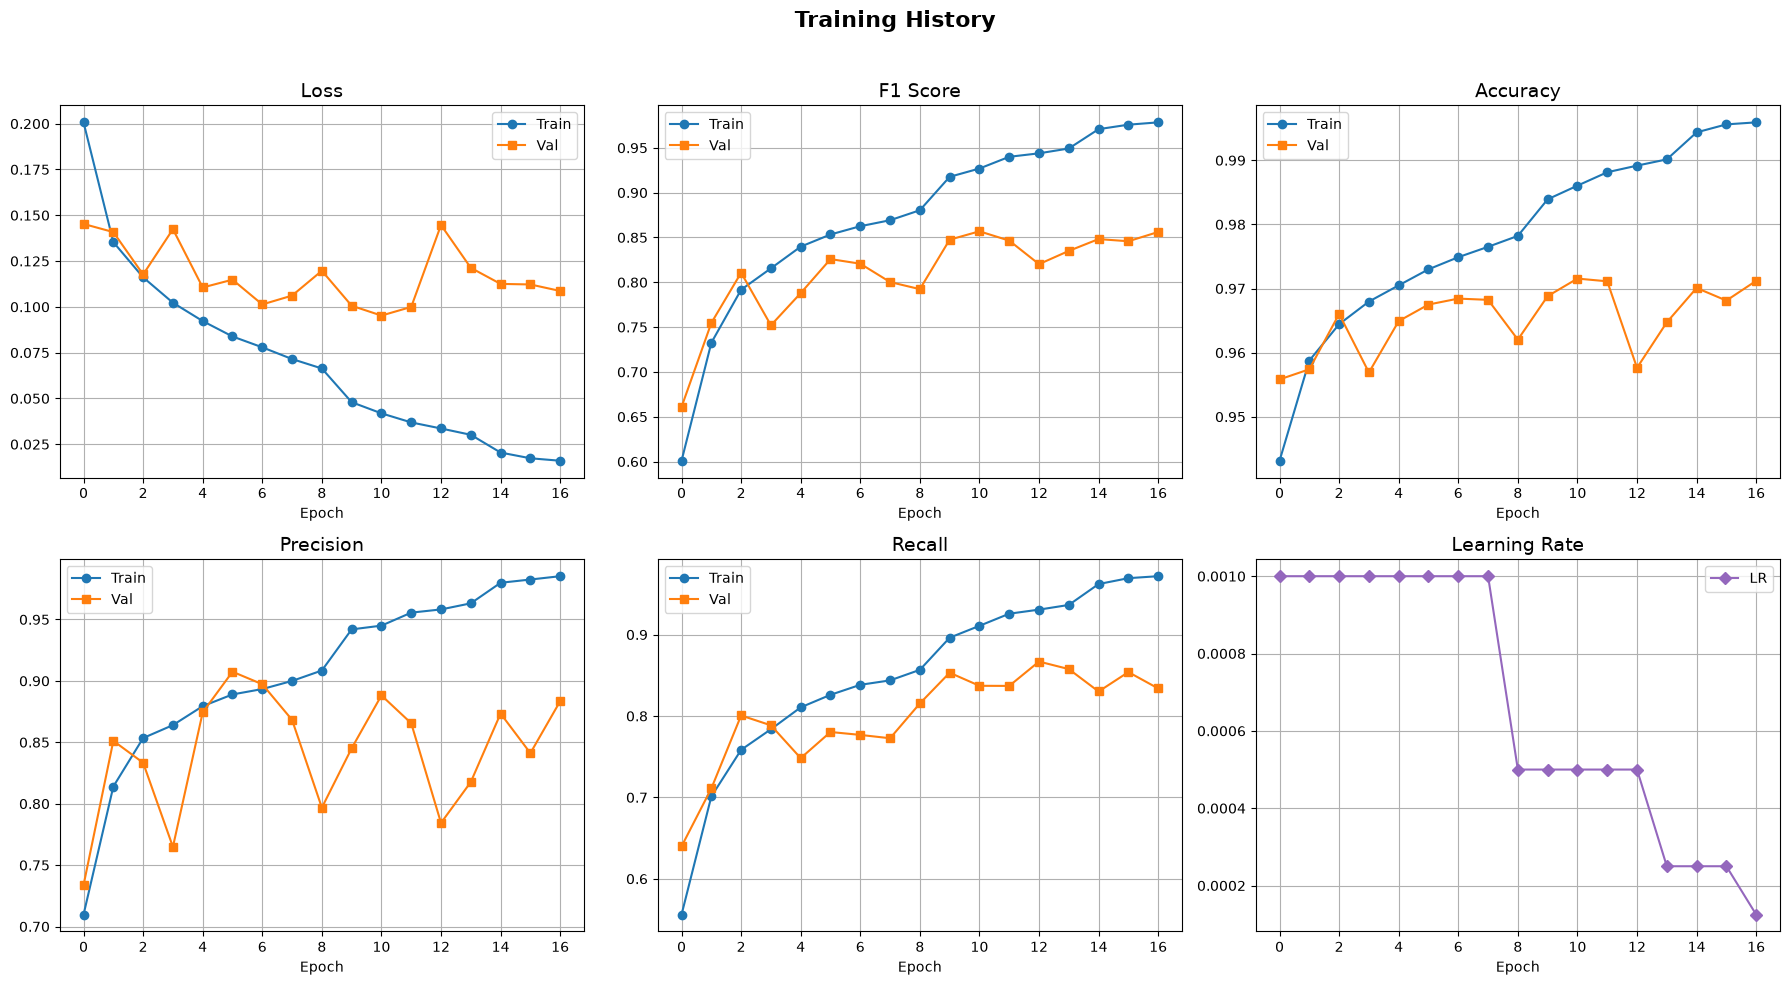

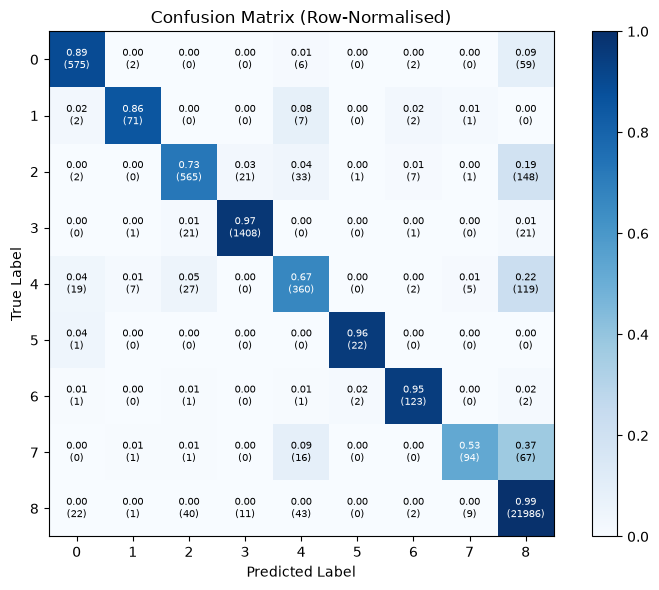


--- Best Val Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.9084 |  0.8554 |     0.7886 |      0.9737 | 0.7164 |      0.9167 |   0.9145 |    0.6505 | 0.9878 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


In [10]:
# Cell 7 — 最終圖表
plot_history(history, show=True)
plot_cm(best_cm, num_classes, show=True)
print("\n--- Best Val Per-Class F1 ---")
print_per_class_f1(best_f1_per_class)

In [11]:
# 推論運行時間
import time

from models.inference import predict
from explain.core import preprocess_wafer_simple

# 量測單樣本推論時間
model.load_state_dict(best_state)
model.eval()
sample_input = test_df.iloc[0]
preprocessed_wafer, _ = preprocess_wafer_simple(sample_input["waferMap"], IMAGE_SIZE, device)

with torch.no_grad():  # warmup
    _ = predict(model, preprocessed_wafer)
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()

N = 100
with torch.no_grad():
    t0 = time.perf_counter()
    for _ in range(N):
        _ = predict(model, preprocessed_wafer)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    t1 = time.perf_counter()

inference_time = (t1 - t0) / N * 1000  # ms per sample
print(f"單樣本推論時間（{N} 次平均）：{inference_time:.3f} ms")

單樣本推論時間（100 次平均）：1.822 ms


In [12]:
# Cell 8 — 儲存結果（選用）
out_dir = make_output_dir(EXPERIMENT_NAME, base="../outputs")
save_results(
    out_dir, model, best_state, best_f1, test_m['f1'], test_m['cm'], test_m['per_class_f1'],
    history, num_classes, LABEL_MAP, IMAGE_SIZE, time_per_epoch,
    inference_time=inference_time, model_name="simple_cnn"
)
print(f"結果已儲存至：{out_dir}")

Results saved to ..\outputs\simple_cnn_20260819_005326
結果已儲存至：..\outputs\simple_cnn_20260819_005326
